# 自动微分模块

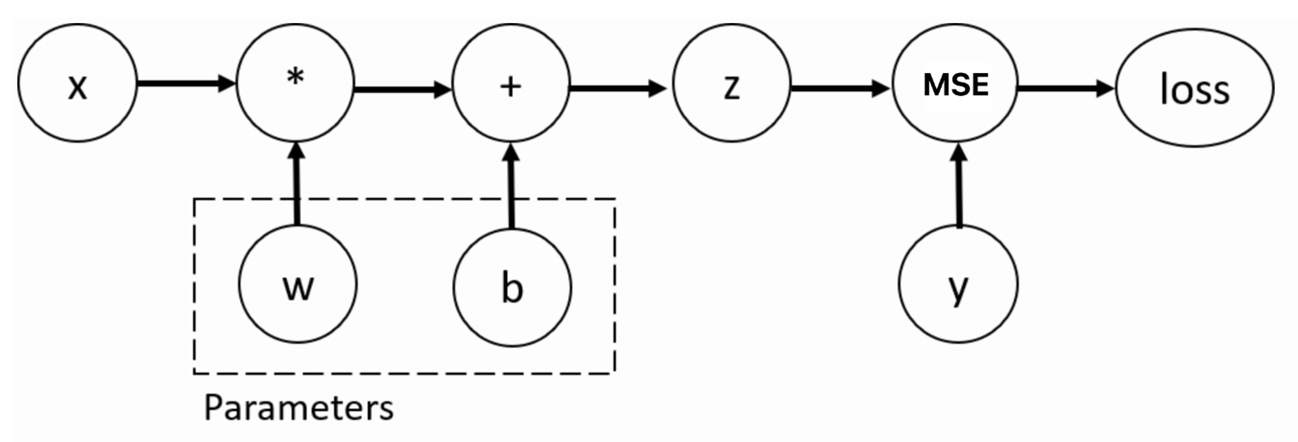

In [15]:
import torch
# (初始值，是否自动微分，数据类型)
w = torch.tensor(10, requires_grad=True, dtype=torch.float)
loss = w**2 + 20
lr = 0.01

for i in range(100):
    # 前向传播
    loss = w**2 + 20
    # 梯度清零(默认梯度会累加)
    # 第一次到这，还没有梯度计算，w.grad = None，要做非空判断
    if w.grad is not None:
        w.grad.zero_()
    # 反向传播
    loss.sum().backward()
    w.data = w.data - lr * w.grad
    print(f'第{i}次,权重：{w:.5f},梯度：{w.grad:.5f},loss：{loss:.5f}')

print(f'最终结果 权重{w:.5f},梯度{w.grad:.5f},loss:{loss:.5f}')

第0次,权重：9.80000,梯度：20.00000,loss：120.00000
第1次,权重：9.60400,梯度：19.60000,loss：116.04000
第2次,权重：9.41192,梯度：19.20800,loss：112.23682
第3次,权重：9.22368,梯度：18.82384,loss：108.58425
第4次,权重：9.03921,梯度：18.44736,loss：105.07632
第5次,权重：8.85842,梯度：18.07842,loss：101.70729
第6次,权重：8.68126,梯度：17.71685,loss：98.47168
第7次,权重：8.50763,梯度：17.36251,loss：95.36420
第8次,权重：8.33748,梯度：17.01526,loss：92.37978
第9次,权重：8.17073,梯度：16.67496,loss：89.51353
第10次,权重：8.00731,梯度：16.34146,loss：86.76079
第11次,权重：7.84717,梯度：16.01463,loss：84.11706
第12次,权重：7.69022,梯度：15.69433,loss：81.57802
第13次,权重：7.53642,梯度：15.38045,loss：79.13953
第14次,权重：7.38569,梯度：15.07284,loss：76.79761
第15次,权重：7.23798,梯度：14.77138,loss：74.54843
第16次,权重：7.09322,梯度：14.47595,loss：72.38831
第17次,权重：6.95135,梯度：14.18643,loss：70.31374
第18次,权重：6.81233,梯度：13.90271,loss：68.32130
第19次,权重：6.67608,梯度：13.62465,loss：66.40778
第20次,权重：6.54256,梯度：13.35216,loss：64.57004
第21次,权重：6.41171,梯度：13.08512,loss：62.80506
第22次,权重：6.28347,梯度：12.82341,loss：61.10998
第23次,权重：6.15780,梯度：12.56695,loss：59.48

## detach() 拷贝一份可类型转换的张量，内存共享

In [16]:
import numpy as np
t1 = torch.tensor([10, 20],requires_grad=True, dtype=torch.float)
print(f't1:{t1}, type(t1):{type(t1)}')
n1 = t1.detach().numpy()
print(f'n1:{n1}, type(n1):{type(n1)}')

t1:tensor([10., 20.], requires_grad=True), type(t1):<class 'torch.Tensor'>
n1:[10. 20.], type(n1):<class 'numpy.ndarray'>


## 模块应用实例

In [17]:
x = torch.ones(2,5)
print(f'x:{x}, type(x):{type(x)}')
y = torch.zeros(2,3)
print(f'y:{y}, type(y):{type(y)}')

# 设定参数
w = torch.randn(5,3,requires_grad=True, dtype=torch.float)
print(f'w:{w}, type(w):{type(w)}')
b = torch.randn(3,requires_grad=True, dtype=torch.float)
print(f'b:{b}, type(b):{type(b)}')

# 前向传播
z = torch.matmul(x,w)+b
print(f'z:{z}, type(z):{type(z)}')

# 定义损失函数
criterion = torch.nn.MSELoss()
loss = criterion(z,y)
print(f'loss:{loss}, type(loss):{type(loss)}')

# 进行自动微分，结合反向传播，更新参数
loss.sum().backward()

print(f'w.grad:{w.grad},b.grad:{b.grad}')


x:tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]), type(x):<class 'torch.Tensor'>
y:tensor([[0., 0., 0.],
        [0., 0., 0.]]), type(y):<class 'torch.Tensor'>
w:tensor([[-0.4134, -1.0774,  1.0168],
        [-0.0115,  0.8444, -0.6238],
        [ 0.8358, -0.1813,  0.9794],
        [ 0.0128,  1.2826, -0.7704],
        [ 0.3294,  2.3775, -0.0168]], requires_grad=True), type(w):<class 'torch.Tensor'>
b:tensor([-0.1720,  0.8096,  0.0812], requires_grad=True), type(b):<class 'torch.Tensor'>
z:tensor([[0.5810, 4.0554, 0.6664],
        [0.5810, 4.0554, 0.6664]], grad_fn=<AddBackward0>), type(z):<class 'torch.Tensor'>
loss:5.742782115936279, type(loss):<class 'torch.Tensor'>
w.grad:tensor([[0.3874, 2.7036, 0.4443],
        [0.3874, 2.7036, 0.4443],
        [0.3874, 2.7036, 0.4443],
        [0.3874, 2.7036, 0.4443],
        [0.3874, 2.7036, 0.4443]]),b.grad:tensor([0.3874, 2.7036, 0.4443])
